# H2 — Regression Discontinuity on Discount Depth

**Hypothesis:** Games discounted ≥50% receive more reviews in the 14 days after sale start than games discounted <50%, due to Steam's front-page visibility threshold.

**Running variable:** SteamSpy discount % (current snapshot).  **Cutoff:** 50%.  **Outcome:** Review count during Winter 2024 sale window (14 days).

In [1]:
import os, json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

sys.path.insert(0, str(Path("..").resolve()))
from src.analysis.rdd import (sharp_rdd, bandwidth_sensitivity,
                               placebo_cutoffs, mccrary_density_test, bootstrap_rdd)

load_dotenv()
RESULTS = Path("../results")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("Ready.")


Ready.


## 1. Load RDD sample

In [2]:
rdd = pd.read_parquet(RESULTS / "eda_rdd_sample.parquet")
print(f"Games with discount data: {len(rdd):,}")
print(f"Discount range: {rdd['discount_pct'].min()}% – {rdd['discount_pct'].max()}%")
print(f"≥50% off: {(rdd['discount_pct'] >= 50).sum():,}   <50% off: {(rdd['discount_pct'] < 50).sum():,}")

# Log-transform outcome for normality
rdd["log_reviews"] = np.log1p(rdd["reviews_14d_post"])
rdd["log_reviews_pre"] = np.log1p(rdd["reviews_30d_pre"])
print(rdd[["discount_pct","reviews_14d_post","log_reviews"]].describe().round(2))


Games with discount data: 232
Discount range: 10% – 95%
≥50% off: 204   <50% off: 28
       discount_pct  reviews_14d_post  log_reviews
count        232.00            232.00       232.00
mean          67.33           1052.76         5.83
std           18.92           2280.51         1.74
min           10.00              0.00         0.00
25%           60.00            154.50         5.05
50%           75.00            366.00         5.91
75%           80.00            904.25         6.81
max           95.00          22800.00        10.03


## 2. Main RDD estimate (bandwidth = 15%)

In [3]:
main = sharp_rdd(rdd, outcome="log_reviews", bandwidth=15.0)
print("=== RDD at 50% cutoff, BW=15 ===")
print(f"  Effect at cutoff: {main['effect_at_cutoff']:+.4f}")
print(f"  SE:   {main['se']:.4f}")
print(f"  95%CI: [{main['ci_low']:+.4f}, {main['ci_high']:+.4f}]")
print(f"  p-value: {main['p_value']:.3f}")
print(f"  N obs: {main['n_obs']}  (above={main['n_above']}, below={main['n_below']})")
sig = "SIGNIFICANT" if main['p_value'] < 0.05 else "not significant"
print(f"  Result: {sig} at 5%")


=== RDD at 50% cutoff, BW=15 ===
  Effect at cutoff: +4.2280
  SE:   4.2687
  95%CI: [-4.1384, +12.5944]
  p-value: 0.322
  N obs: 58  (above=51, below=7)
  Result: not significant at 5%


## 3. RDD plot — fitted lines either side of cutoff

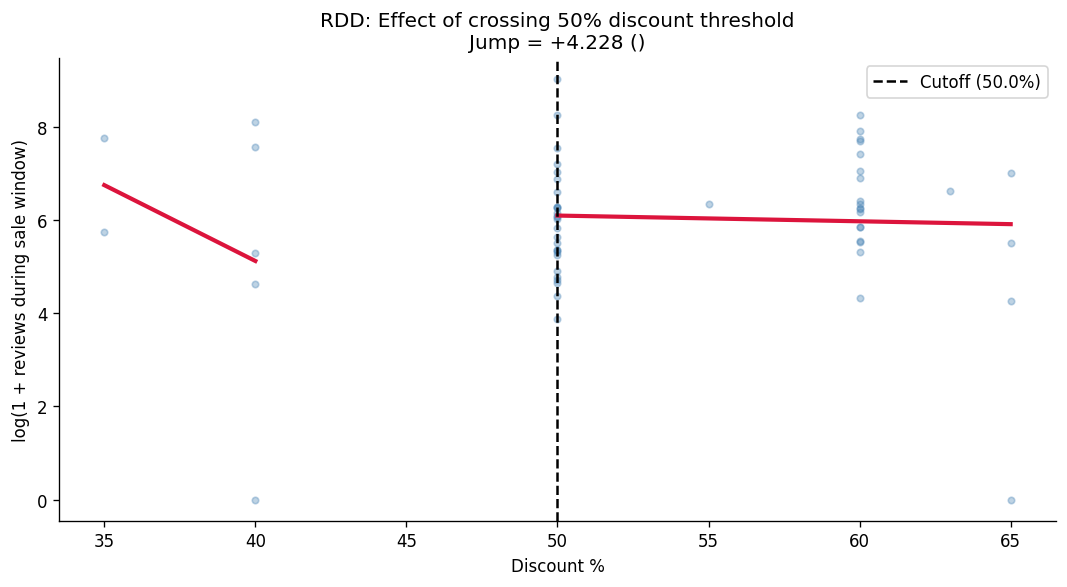

In [4]:
cutoff = 50.0
bw = 15.0
band = rdd[(rdd["discount_pct"] >= cutoff - bw) & (rdd["discount_pct"] <= cutoff + bw)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(band["discount_pct"], band["log_reviews"], alpha=0.35, s=15, color="steelblue")

for above in [False, True]:
    sub = band[band["discount_pct"] >= cutoff] if above else band[band["discount_pct"] < cutoff]
    if len(sub) < 3:
        continue
    from numpy.polynomial import polynomial as P
    x = sub["discount_pct"].values
    y = sub["log_reviews"].values
    coeffs = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.polyval(coeffs, xs), color="crimson", lw=2.5)

ax.axvline(cutoff, color="black", ls="--", lw=1.5, label=f"Cutoff ({cutoff}%)")
ax.set_xlabel("Discount %")
ax.set_ylabel("log(1 + reviews during sale window)")
ax.set_title(f"RDD: Effect of crossing 50% discount threshold\n"
             f"Jump = {main['effect_at_cutoff']:+.3f} ({'' if main['p_value']>=0.05 else 'p<0.05'})")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_rdd_main.png", dpi=150)
plt.show()


## 4. Bandwidth sensitivity

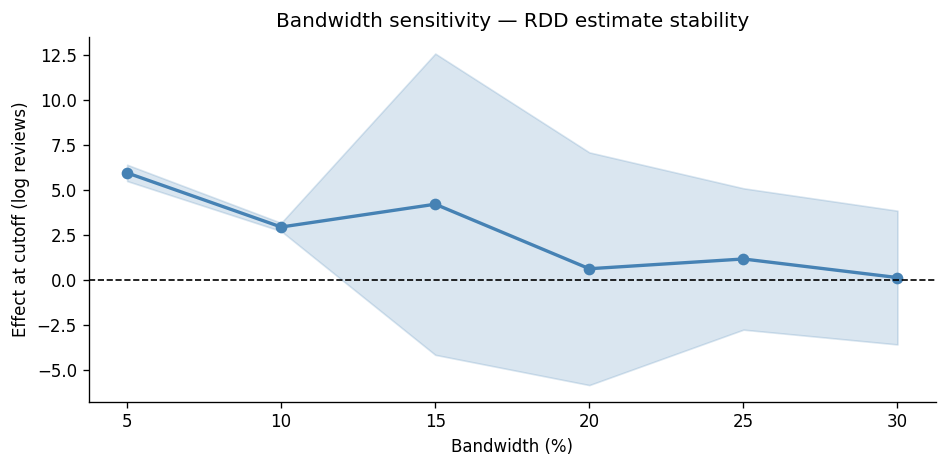

  BW=   5%  effect=+5.9677  SE=0.2311  p=0.000 *
  BW=  10%  effect=+2.9612  SE=0.1168  p=0.000 *
  BW=  15%  effect=+4.2280  SE=4.2687  p=0.322  
  BW=  20%  effect=+0.6438  SE=3.2972  p=0.845  
  BW=  25%  effect=+1.1862  SE=2.0033  p=0.554  
  BW=  30%  effect=+0.1533  SE=1.8950  p=0.936  


In [5]:
bw_results = bandwidth_sensitivity(rdd, outcome="log_reviews")

bws   = [r["bandwidth"] for r in bw_results if "error" not in r]
effs  = [r["effect_at_cutoff"] for r in bw_results if "error" not in r]
cis_l = [r["ci_low"]  for r in bw_results if "error" not in r]
cis_h = [r["ci_high"] for r in bw_results if "error" not in r]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bws, effs, marker="o", color="steelblue", lw=2)
ax.fill_between(bws, cis_l, cis_h, alpha=0.2, color="steelblue")
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Bandwidth (%)")
ax.set_ylabel("Effect at cutoff (log reviews)")
ax.set_title("Bandwidth sensitivity — RDD estimate stability")
plt.tight_layout()
plt.savefig(RESULTS / "fig_rdd_bandwidth.png", dpi=150)
plt.show()

for r in bw_results:
    if "error" not in r:
        sig = "*" if r["p_value"] < 0.05 else " "
        print(f"  BW={r['bandwidth']:4.0f}%  effect={r['effect_at_cutoff']:+.4f}  "
              f"SE={r['se']:.4f}  p={r['p_value']:.3f} {sig}")


## 5. McCrary density test (manipulation check)

=== McCrary density test ===
  N below cutoff: 7  N above: 51
  Density below: 0.47  above: 3.40
  Density ratio (above/below): 7.29
  Manipulation concern: YES — bunching may invalidate RDD


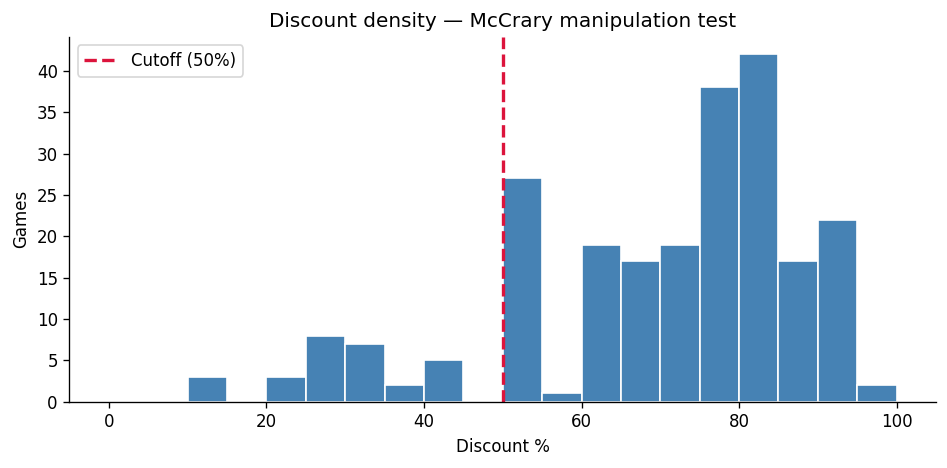

In [6]:
density = mccrary_density_test(rdd)
print("=== McCrary density test ===")
print(f"  N below cutoff: {density['n_below']}  N above: {density['n_above']}")
print(f"  Density below: {density['density_below']:.2f}  above: {density['density_above']:.2f}")
print(f"  Density ratio (above/below): {density['density_ratio']:.2f}")
concern = "YES — bunching may invalidate RDD" if density["manipulation_concern"] else "No concern"
print(f"  Manipulation concern: {concern}")

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rdd["discount_pct"], bins=range(0, 101, 5), color="steelblue", edgecolor="white")
ax.axvline(50, color="crimson", ls="--", lw=2, label="Cutoff (50%)")
ax.set_xlabel("Discount %")
ax.set_ylabel("Games")
ax.set_title("Discount density — McCrary manipulation test")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_rdd_mccrary.png", dpi=150)
plt.show()


## 6. Placebo cutoffs

=== Placebo cutoffs (should show null effects) ===
  Cutoff= 20%  BW=15  effect=+2.3183  p=0.000 * SIGNIFICANT
  Cutoff= 30%  BW=15  effect=-3.1190  p=0.272 
  Cutoff= 40%  BW=15  effect=-0.9763  p=0.645 
  Cutoff= 60%  BW=15  effect=-0.5388  p=0.135 
  Cutoff= 70%  BW=15  effect=-0.7662  p=0.261 
  Cutoff= 80%  BW=15  effect=-0.3509  p=0.513 


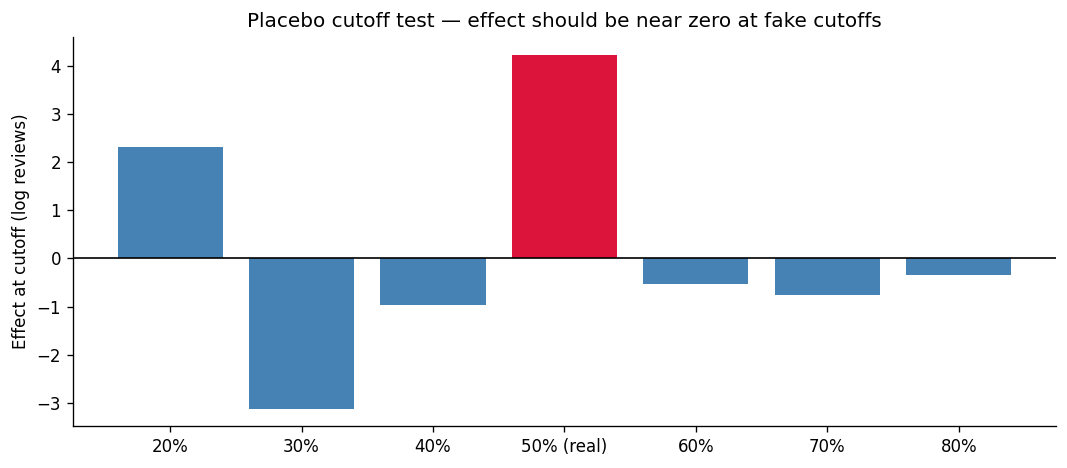

In [7]:
placebos = placebo_cutoffs(rdd, outcome="log_reviews")
print("=== Placebo cutoffs (should show null effects) ===")
placebo_cutoff_vals = [20, 30, 40, 60, 70, 80]
for c, r in zip(placebo_cutoff_vals, placebos):
    if "error" not in r:
        sig = "* SIGNIFICANT" if r["p_value"] < 0.05 else ""
        print(f"  Cutoff={c:3d}%  BW=15  "
              f"effect={r['effect_at_cutoff']:+.4f}  p={r['p_value']:.3f} {sig}")

# Patch cutoff into results for display
placebo_results_with_c = []
for c, r in zip(placebo_cutoff_vals, placebos):
    if "error" not in r:
        placebo_results_with_c.append({**r, "cutoff": c})

fig, ax = plt.subplots(figsize=(9, 4))
real_cutoffs  = [main["effect_at_cutoff"]]
real_labels   = ["50% (real)"]
placebo_effs  = [r["effect_at_cutoff"] for r in placebo_results_with_c]
placebo_labels = [f"{r['cutoff']}%" for r in placebo_results_with_c]
all_labels = placebo_labels[:3] + real_labels + placebo_labels[3:]
all_effs   = placebo_effs[:3]   + real_cutoffs + placebo_effs[3:]
colors = ["steelblue"] * 3 + ["crimson"] + ["steelblue"] * 3
ax.bar(all_labels, all_effs, color=colors)
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("Effect at cutoff (log reviews)")
ax.set_title("Placebo cutoff test — effect should be near zero at fake cutoffs")
plt.tight_layout()
plt.savefig(RESULTS / "fig_rdd_placebo.png", dpi=150)
plt.show()


## 7. Bootstrap CI + save results

In [8]:
boot = bootstrap_rdd(rdd, outcome="log_reviews", bandwidth=15.0, n_bootstrap=500)
print(f"Bootstrap 95% CI: [{boot['bootstrap_ci_low']:+.4f}, {boot['bootstrap_ci_high']:+.4f}]")
print(f"Bootstrap SE: {boot['bootstrap_se']:.4f}")

h2_results = {
    "effect_at_cutoff": main["effect_at_cutoff"],
    "se": main["se"],
    "ci_low": main["ci_low"],
    "ci_high": main["ci_high"],
    "p_value": main["p_value"],
    "bootstrap_ci_low": boot["bootstrap_ci_low"],
    "bootstrap_ci_high": boot["bootstrap_ci_high"],
    "manipulation_concern": density["manipulation_concern"],
    "n_obs": main["n_obs"],
}
import json
with open(RESULTS / "h2_rdd_results.json", "w") as f:
    json.dump(h2_results, f, indent=2)
print(json.dumps(h2_results, indent=2))


Bootstrap 95% CI: [-3.5029, +12.8754]
Bootstrap SE: 4.1059
{
  "effect_at_cutoff": 4.228001178915495,
  "se": 4.268650247119847,
  "ci_low": -4.138399568037407,
  "ci_high": 12.594401925868397,
  "p_value": 0.32194087825313455,
  "bootstrap_ci_low": -3.502936732439153,
  "bootstrap_ci_high": 12.875425500296956,
  "manipulation_concern": true,
  "n_obs": 58
}
